### Coffee & Coding - Survey Comment Classification : Keyword matching vs TD-IDF vs SetFit

#### The question we are answering today

***"Given a free-text workplace survey comment, can we automatically classify it into a theme?"***

# Plan

| Section | Topic
|---|---|
| 01 | Install relevant libraries
| 02 | The data - what are we working with?
| 03 | Approach 1 - Keyword matching
| 04 | Approach 2 - ML classifier (scikit-learn)
| 05 | Approach 3 - SetFit
| 06 | Comparison

We will need GPU for training model in the later stage. Go to **Runtime** and select **Change runtime Type** and select **T4 GPU**

In [1]:
# Install required libraries
# This may take 1-2 minutes the first time
# Versions are pinned to a combination known to work together.

import os
# Note, we not now allowed to do this in Fabric due to recent python package attack
%pip install -q scikit-learn pandas numpy matplotlib seaborn
%pip install -q "setfit==1.1.0" "transformers==4.44.2" "sentence-transformers==3.0.1" "accelerate==0.34.2" "datasets==2.21.0"

import transformers
needs_restart = transformers.__version__ != "4.44.2"

if needs_restart:
    print("Installed the correct versions, but this Colab session had a different")
    print("version already loaded. Restarting the runtime now to apply it --")
    print("this is expected. When it reconnects, just click 'Run all' again.")
    os.kill(os.getpid(), 9)
else:
    print("All libraries installed and loaded correctly -- no restart needed")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.2/75.2 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 32.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 227.1/227.1 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 324.4/324.4 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.3/527.3 kB 19.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 177.6/177.6 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 17.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 42.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 6.20.0 requires huggingfa

We will need GPU in the later stage (train model using `SetFit`) so let's check if we change the runtime

In [2]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using devide: {device}")

# Check which GPU is attached, it not we will need to change setting
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
else:
    print("No GPU detected, go to Runtime -> Change runtime type -> GPU and you will need to RESTART runtime and re-run from the top")

Using devide: cuda
GPU: Tesla T4


In [3]:
# Import everything we'll need
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# scikit-learn — the ML library
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# SetFit
import transformers
assert transformers.__version__ == "4.44.2", (
    f"transformers is version {transformers.__version__}, expected 4.44.2. "
    "Go to Runtime > Restart runtime, then run all cells again from the top."
)
from setfit import SetFitModel, Trainer, TrainingArguments
from datasets import Dataset

print("All imports successful")


All imports successful


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


# The Data
## What datawet are we using?

We are using the Glassdoor Job Reviews dataset from [Kaggle](https://www.kaggle.com/datasets/davidgauthier/glassdoor-job-reviews) as inspiration. It contains real workplace comments written by employees about their jobs, things like:


*   "Great work-life balance, very flexible hours"
*   "Management doesn't listen to feedback"
*   "No opportunities to grow or develop skills"

We think the customer survey would be similar, they have different themes, but with free-text responses about how they feel about our service."

### For our session, we have 4 classification themes

We will classify each comment into one of these themes

| Theme | What it covers|Example
|---|---|---|
| `work_life_balance` | Hours, flexibility, workload,stress| "Too many hours, no flexibility"
| `management` | Managers, leadership, communication| "My manager always gives feedback"
| `career_growth` | Training, development, progression | "No promotion opportunities here"
| `culture` | Team, environment, values, inclusion | "Great team atmosphere, very supportive"

We have created synthetic `workplace_survey_comments.csv` data. We used Copilot to generate 400 comments across our 4 themes. Each theme is a 60/40 mix of two styles:



*   Direct comments - say the theme in obvious words. For example, "flexible hours", "my manager", "training opportunities". These are easy to spot, for a computer and for a human
*   Indirect comments - get across the same idea, but without using any of the obvious words. The meaning is more nuanced; you have to read between the lines - the tone rather than spot a keyword. For example, instead of writing "good work-life balance", someome might write "I'm exhausted every single evening". There is no work-life-balance vocabulary in there at all, but the meaning is obvious for human reader.


**Why mix the two together?** Because comments aren't split neatly into "easy" and "hard". Real feedback comes in both flavours, and covers both good and bad experiences either way. If we only tested on the easy, direct comments, keyword matching would look far better than it really is. Mixing in the indirect comments, the ones with no obvious keywords, gives us an better test. It shows us which methods can genuinely understand what someone means, and which ones are just spotting words.













In [4]:
# Load dataset
# Reads straight from the GitHub repo -- no upload needed.
# Falls back to a local file, then a manual upload, if the URL ever fails.

import pandas as pd
import os

CSV_URL = (
    "https://raw.githubusercontent.com/nhsbsa-data-analytics/coffee-and-coding/"
    "survey-comments/2026-07-29%20Classifying%20Survey%20Comments/"
    "workplace_survey_synthetic_comments.csv"
)
CSV_FILENAME = "workplace_survey_comments.csv"

try:
    df = pd.read_csv(CSV_URL)
    print(f"Loaded from GitHub: {CSV_URL}")
except Exception as e:
    print(f"Could not load from URL ({e}), falling back...")
    if os.path.exists(CSV_FILENAME):
        df = pd.read_csv(CSV_FILENAME)
        print(f"Loaded from local file: {CSV_FILENAME}")
    else:
        try:
            from google.colab import files
            print(f"Please select '{CSV_FILENAME}' in the upload dialog...")
            uploaded = files.upload()
            CSV_FILENAME = list(uploaded.keys())[0]
            df = pd.read_csv(CSV_FILENAME)
        except ImportError:
            raise FileNotFoundError(
                f"Could not find {CSV_FILENAME} -- check CSV_URL or upload manually."
            )

print(f"\nDataset shape: {df.shape}")
print(f"\nTheme distribution:")
print(df["theme"].value_counts())
print(f"\nDifficulty split (per theme: 60 direct, 40 indirect):")
print(df["difficulty"].value_counts())
print(f"\nSample comments:")
df.sample(8, random_state=42)[["theme", "difficulty", "comment"]]

Loaded from GitHub: https://raw.githubusercontent.com/nhsbsa-data-analytics/coffee-and-coding/survey-comments/2026-07-29%20Classifying%20Survey%20Comments/workplace_survey_synthetic_comments.csv

Dataset shape: (400, 3)

Theme distribution:
theme
career_growth        100
work_life_balance    100
culture              100
management           100
Name: count, dtype: int64

Difficulty split (per theme: 60 direct, 40 indirect):
difficulty
direct      240
indirect    160
Name: count, dtype: int64

Sample comments:


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,theme,difficulty,comment
209,management,indirect,Whoever's in charge treats mistakes as somethi...
280,work_life_balance,direct,Good balance between work demands and personal...
33,work_life_balance,direct,Working from home just means working longer hours
210,career_growth,direct,Internal vacancies are filled externally which...
93,career_growth,direct,No training opportunities whatsoever in this role
84,career_growth,indirect,I had to leave to actually move forward
329,management,indirect,Whoever I report to actually listens when I ra...
94,management,indirect,I know exactly what's expected of me each week


##### Visualise the class distribution

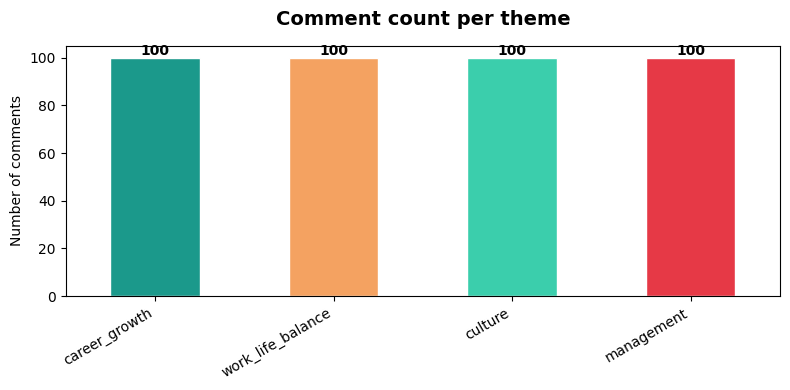

Balanced dataset — 100 comments per theme


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [5]:
# Visualise the class distribution
fig, ax = plt.subplots(figsize=(8, 4))
colors = ['#1B998B', '#F4A261', '#3BCEAC', '#E63946']
df['theme'].value_counts().plot(kind='bar', ax=ax, color=colors, edgecolor='white')
ax.set_title('Comment count per theme', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('')
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
ax.set_ylabel('Number of comments')
for p in ax.patches:
    ax.annotate(str(int(p.get_height())),
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.show()
print("Balanced dataset — 100 comments per theme")


#### Note on class balance

This dataset is perfectly balanced. (Exactly 100 comments per theme) well, because we built it that way on purpose, to keep our comparision fair and easy to follow.

Real data is almost never this tidy! In practice, you will most definitely see class imbalance. Some themes come up far more often than others. That matters because:

*   A model can get a misleadingly high accuracy just by favouring the monority theme
*   Minority themes are the ones most likely to get missed or misclasified
*   Accuracy alone can hide this - metrics like **precision**, **recall**, and **F1 per class**

So, when we take these methods to real data, check theme distribution first, and read the per-class scores.



# Approach 1: Keyword matching

### The idea

The simplest possible approach: we write a list of keywords for each theme, then check if a comment contains any of them.

This is rule based classification.

`comment -> does it contain "hours", "flexible", "workload"? -> work_life_balance`

`comment -> does it contain "manager", "leadership", "communication"? -> management`

`-.... and so on.....`

#### Why we try this?

Easy to understand, easy to explain to stakeholders, and it works - up to a point. We will try and see what is its limitation



In [6]:
# EYWORD DICTIONARY
# We define keywords for each theme.
# A comment is assigned the theme whose keywords appear most in the text.

keyword_rules = {
    'work_life_balance': [
        'hours', 'flexible', 'workload', 'balance', 'stress', 'overtime',
        'weekend', 'evenings', 'remote', 'home', 'leave', 'holiday',
        'burnout', 'burnt out', 'pressure', 'time', 'lunch', 'commute',
        'part-time', 'contracted', 'switch off', 'boundary'
    ],
    'management': [
        'manager', 'management', 'leadership', 'leader', 'supervisor',
        'micromanage', 'feedback', 'communication', 'transparent',
        'senior', 'direction', 'decision', 'support', 'approachable',
        'recognition', 'mentor', 'coach', 'line manager', 'bully'
    ],
    'career_growth': [
        'training', 'development', 'promotion', 'career', 'progression',
        'opportunity', 'qualifications', 'skills', 'learning', 'grow',
        'course', 'appraisal', 'secondment', 'mentoring', 'potential',
        'internal', 'external', 'sponsorship', 'graduate', 'talent'
    ],
    'culture': [
        'culture', 'team', 'inclusive', 'diversity', 'values', 'belonging',
        'toxic', 'blame', 'trust', 'psychological safety', 'colleagues',
        'environment', 'community', 'wellbeing', 'edi', 'respect',
        'bullying', 'harassment', 'purpose', 'mission', 'politics'
    ]
}

print("Keyword counts per theme:")
for theme, keywords in keyword_rules.items():
    print(f"  {theme}: {len(keywords)} keywords")


Keyword counts per theme:
  work_life_balance: 22 keywords
  management: 19 keywords
  career_growth: 20 keywords
  culture: 21 keywords


Let's define our classification function.


In [7]:
# For each comment, count how many keywords from each theme appear.
# Assign the theme with the highest count.
# If no keywords match at all, return 'unclassified'.

def classify_with_keywords(comment, rules):
    # Lowercase the comment so matching isn't case-sensitive
    # otherwise 'Manager' and 'manager' would be treated as different words.
    comment_lower = comment.lower()

    # This will hold a running keyword-count for every theme, e.g.
    # {'work_life_balance': 0, 'management': 0, 'career_growth': 0, 'culture': 0}
    # It starts empty and gets filled in by the loop below.
    scores = {}

    # `rules` is our keyword_rules dictionary , e.g.
    #   {'work_life_balance': ['hours', 'flexible', ...], 'management': [...], ...}
    #
    # rules.items() turns that dictionary into a sequence of (key, value) pairs:
    #   ('work_life_balance', ['hours', 'flexible', ...])
    #   ('management', ['manager', 'leadership', ...])
    #   ('career_growth', ['training', 'development', ...])
    #   ('culture', ['culture', 'team', ...])
    #
    # `for theme, keywords in rules.items():` unpacks each pair as it goes --
    # on the first loop, theme = 'work_life_balance' and
    # keywords = ['hours', 'flexible', 'workload', ...]. On the next loop,
    # theme = 'management' and keywords = ['manager', 'leadership', ...], and so on.
    for theme, keywords in rules.items():

        # Count how many keywords from THIS theme appear anywhere in the comment.
        #
        # Reading the generator expression from the inside out:
        #   for kw in keywords            -> loop over every keyword in this theme's list
        #   if kw in comment_lower         -> keep only the ones that appear in the comment
        #   sum(1 for kw in keywords ...)  -> add 1 for every keyword that matched, giving a total count
        #
        # Example: comment_lower = 'i feel completely burnt out from the workload'
        # and keywords = ['hours', 'flexible', 'workload', 'burnt out', 'stress', ...]
        #   'hours'      in comment_lower? No  -> +0
        #   'flexible'   in comment_lower? No  -> +0
        #   'workload'   in comment_lower? Yes -> +1
        #   'burnt out'  in comment_lower? Yes -> +1
        #   'stress'     in comment_lower? No  -> +0
        #   ... (rest of the keywords) ...
        #   total score = 2
        score = sum(1 for kw in keywords if kw in comment_lower)

        # Store that count against its theme name, e.g. scores['work_life_balance'] = 2
        scores[theme] = score

    # After the loop above finishes, `scores` holds one count per theme, e.g.:
    #   {'work_life_balance': 2, 'management': 0, 'career_growth': 0, 'culture': 0}

    # max() normally compares the things you give it directly -- but we don't want
    # to compare the theme NAMES (that would just sort them alphabetically).
    # We want to compare their SCORES instead. `key=scores.get` tells max() to
    # look up scores.get(theme) for every theme, and use THAT value for the
    # comparison, while still returning the theme name (the key) that scored highest.
    #
    # For {'work_life_balance': 2, 'management': 0, 'career_growth': 0, 'culture': 0}
    # this returns 'work_life_balance', because 2 is the highest score.
    best_theme = max(scores, key=scores.get)

    # Now look up the winning theme's actual score, using best_theme as the key.
    # Following the example above: best_score = scores['work_life_balance'] = 2
    best_score = scores[best_theme]

    # If every theme scored 0, nothing matched at all -- none of our keywords
    # appeared anywhere in the comment. In that case we don't want to guess,
    # so we return 'unclassified' rather than picking an arbitrary theme.
    if best_score == 0:
        return 'unclassified'

    # Otherwise, return the name of the theme with the highest keyword count.
    return best_theme


# Test it on a few examples
test_comments = [
    "My manager never gives useful feedback",
    "I feel completely burnt out from the workload",
    "No training opportunities available here",
    "The team culture is toxic and blame-heavy",
    "Really enjoyed working here",   # vague
]

print("Testing keyword classifier:\n")
for comment in test_comments:
    prediction = classify_with_keywords(comment, keyword_rules)
    print(f"  Comment : {comment}")
    print(f"  Predicted: {prediction}\n")


Testing keyword classifier:

  Comment : My manager never gives useful feedback
  Predicted: management

  Comment : I feel completely burnt out from the workload
  Predicted: work_life_balance

  Comment : No training opportunities available here
  Predicted: career_growth

  Comment : The team culture is toxic and blame-heavy
  Predicted: culture

  Comment : Really enjoyed working here
  Predicted: unclassified



Note: If two themes scores equally, this function silently returns whicheover theme, we will need to modify code

In [8]:
# Apply the keyword classifier to all 400 comments and measure accuracy

df['keyword_prediction'] = df['comment'].apply(
    lambda x: classify_with_keywords(x, keyword_rules)
)

# Calculate accuracy — but exclude 'unclassified' from the count
classified_mask = df['keyword_prediction'] != 'unclassified'
classified_df = df[classified_mask]

keyword_accuracy = accuracy_score(
    classified_df['theme'],
    classified_df['keyword_prediction']
)

# The fairer, real-world number: treat "couldn't classify it" as a wrong answer,
# since a comment silently dropped from your report is still a miss.
overall_accuracy = accuracy_score(df['theme'], df['keyword_prediction'])

unclassified_count = (~classified_mask).sum()
unclassified_pct = unclassified_count / len(df) * 100

print(f"Keyword Classifier Results")
print(f"══════════════════════════")
print(f"Total comments             : {len(df)}")
print(f"Classified                 : {classified_mask.sum()} ({100 - unclassified_pct:.0f}%)")
print(f"Unclassified               : {unclassified_count} ({unclassified_pct:.0f}%)")
print(f"Accuracy (on classified only): {keyword_accuracy:.1%}")
print(f"Accuracy (overall, unclassified = wrong): {overall_accuracy:.1%}")

# Break it down by difficulty — this is the key insight
print(f"\nBreakdown by comment style:")
for diff in ['direct', 'indirect']:
    sub = df[df['difficulty'] == diff]
    sub_classified = sub[sub['keyword_prediction'] != 'unclassified']
    cov = len(sub_classified) / len(sub)
    acc = accuracy_score(sub_classified['theme'], sub_classified['keyword_prediction']) if len(sub_classified) else 0
    print(f"  {diff:10s}: coverage={cov:.0%}, accuracy on classified={acc:.0%}")


Keyword Classifier Results
══════════════════════════
Total comments             : 400
Classified                 : 239 (60%)
Unclassified               : 161 (40%)
Accuracy (on classified only): 77.0%
Accuracy (overall, unclassified = wrong): 46.0%

Breakdown by comment style:
  direct    : coverage=84%, accuracy on classified=81%
  indirect  : coverage=23%, accuracy on classified=54%


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


"Accuracy on classified" only marks the comments the keyword matcher actually attempted, it quietly skips anything it couldn't match to a keyword. "Overall accuracy" counts those skipped comments as wrong too, because that's what really happens to them in practice. The coverage number shows how big that blind spot is.

The direct vs indirect breakdown makes this more clear. Watch for coverage dropping a lot on indirect comments, while accuracy on the ones it *did* classify stays high. That's the core problem with keyword matching: it sounds confident when it works, but it has no idea when it's missed something. Also, unclassfied ones, human constatntly add keywords.

In [9]:
# Let's look at the mistakes — which comments got the wrong theme?

mistakes = df[
    (df['keyword_prediction'] != df['theme']) &
    (df['keyword_prediction'] != 'unclassified')
]

print(f"Misclassified comments: {len(mistakes)}\n")
print("Examples of mistakes:")
print("─" * 80)
for _, row in mistakes.head(6).iterrows():
    print(f"  Comment   : {row['comment'][:80]}")
    print(f"  Actual    : {row['theme']}")
    print(f"  Predicted : {row['keyword_prediction']}")
    print()


Misclassified comments: 55

Examples of mistakes:
────────────────────────────────────────────────────────────────────────────────
  Comment   : Mentoring programme is very well structured
  Actual    : career_growth
  Predicted : management

  Comment   : I led something end-to-end for the first time recently
  Actual    : career_growth
  Predicted : work_life_balance

  Comment   : Someone senior actually invested time showing me the ropes
  Actual    : career_growth
  Predicted : work_life_balance

  Comment   : Qualifications are not valued or supported here
  Actual    : career_growth
  Predicted : management

  Comment   : There's a transparent process for applying to internal roles
  Actual    : career_growth
  Predicted : management

  Comment   : Management invests in the team's wellbeing
  Actual    : management
  Predicted : culture



These mistakes show the same weakness from a different angle: keyword matching can't tell which word actually carries the meaning of a sentence, so it just grabs whichever keyword shows up, even if it's incidental. "Mentoring programme is very well structured" gets called `management` because "mentor" is on the management list, even though the sentence is really about career development. "Management invests in the team's wellbeing" gets called `culture` because "wellbeing" is a culture keyword, overriding the fact that "management" is right there too. The method has no sense of which word is the main subject of the sentence and which is just supporting detail. It treats every keyword hit as equally important, so a single word from the wrong list is enough to derail the whole prediction.

#### Why does keyword matching fail?



1.   Context blindness on indirect language: Comments like "nobody above me taks credit for my work" don't contain any of our listed keywords, so they cah't be classified at all. This is the biggest real-world failure mode. On the indirect comments in our dataset, keyword matching's coverage drops sharply.
2.   Overlapping keywords: For example, the word "support" can appear in both management and work-life-balance context
3.   Missing vocabulary: If a comment uses synonyms you haven't listed, it gets missed entirely
4.   Rigid rules: Every new pattern requires a human to update them the list manually.

The next two approaches fix this because they don't rely on spotting exact words (or phrases) - they learn **patterns**





# Approach 2: ML Classifier (scikit-learn)

### The idea

Instead of us writing the rules by hand, we let the model figure out which words matter; by learning from examples we've already labelled.

There are two steps to this:

**Step 1** : Turn words into numbers. A computer can'twork with raw text, so we convert each comment into a set of numbers, one per word, using a method called TF-IDF. Words that are common and useful for spotting a particular theme get a high number and generic filler words (stopwords etc) get pushed close to zero.


**Setp 2** : Learn which numbers predict which theme. Once every comment is just a row of numbers, a logistic regression model looks across all our labelled examples and learns which numbers tend to go with which theme. This is the same mechanism as the perceptron from the slide deck: numbers go in, each one gets a weight, they're added up, and the total decides the answer.

The key difference from keyword matching: nobody tells the model which words matter in advance. It works out for itself from the data


In [10]:
# We split our data:
#   - 80% for training (the model learns from these)
#   - 20% for testing  (we evaluate on these — the model has never seen them)
#
# we train on historical data,
# then evaluate how well it works on new, unseen comments.

X_train, X_test, y_train, y_test = train_test_split(
    df['comment'],      # the text
    df['theme'],        # the label
    test_size=0.2,      # 20% held back for testing
    random_state=42,    # so results are reproducible
    stratify=df['theme'] # ensure each theme is represented in both splits
)

print(f"Training set : {len(X_train)} comments")
print(f"Test set     : {len(X_test)} comments")
print(f"\nTheme distribution in test set:")
print(y_test.value_counts())


Training set : 320 comments
Test set     : 80 comments

Theme distribution in test set:
theme
management           20
culture              20
career_growth        20
work_life_balance    20
Name: count, dtype: int64


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [11]:
# TF-IDF VECTORISATION
# Convert text to numbers.
# Each comment becomes a row of numbers one number per word in our vocabulary.

vectorizer = TfidfVectorizer(
    max_features=500,    # only keep the 500 most useful words
    ngram_range=(1, 2),  # consider single words AND pairs (e.g. "work life")
    stop_words='english' # remove common words like "the", "a", "is"
)

# Fit on training data, transform both train and test
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec  = vectorizer.transform(X_test)

print(f"Training matrix shape: {X_train_vec.shape}")
print(f"{X_train_vec.shape[0]} comments, {X_train_vec.shape[1]} word features")


Training matrix shape: (320, 500)
320 comments, 500 word features


In [12]:
# TRAIN THE CLASSIFIER
# Logistic Regression learns which word features predict which theme.


classifier = LogisticRegression(
    max_iter=1000,       # maximum training iterations
    random_state=42,
    C=1.0                # regularisation strength (higher = less regularised)
)

classifier.fit(X_train_vec, y_train)

print("Model trained successfully")


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:451: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  opt_res = optimize.minimize(


Model trained successfully


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [13]:
#  EVALUATE
y_pred_sklearn = classifier.predict(X_test_vec)

sklearn_accuracy = accuracy_score(y_test, y_pred_sklearn)
print(f"scikit-learn Classifier Accuracy: {sklearn_accuracy:.1%}")
print()
print("Full classification report:")
print("─" * 60)
print(classification_report(y_test, y_pred_sklearn, target_names=sorted(df['theme'].unique())))


scikit-learn Classifier Accuracy: 63.7%

Full classification report:
────────────────────────────────────────────────────────────


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


                   precision    recall  f1-score   support

    career_growth       0.65      0.65      0.65        20
          culture       0.50      0.60      0.55        20
       management       0.72      0.65      0.68        20
work_life_balance       0.72      0.65      0.68        20

         accuracy                           0.64        80
        macro avg       0.65      0.64      0.64        80
     weighted avg       0.65      0.64      0.64        80



/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


66.7% accuracy - this is better than keyword matching, and every comment gets a prediction (we didn't have `unclassifed`)

The breakdown shows where it struggles; `culture` is the weak splt. `management` and `work_life_balance` is the most reliable, when model picks them, it's usually right, though it still misses about a thrid of the real caes in each.

So the model doesn't fail evenly, it has specific blind spots, and knowing which theme is weakest is exactly what tells us where to focus if we wanted to improve it.


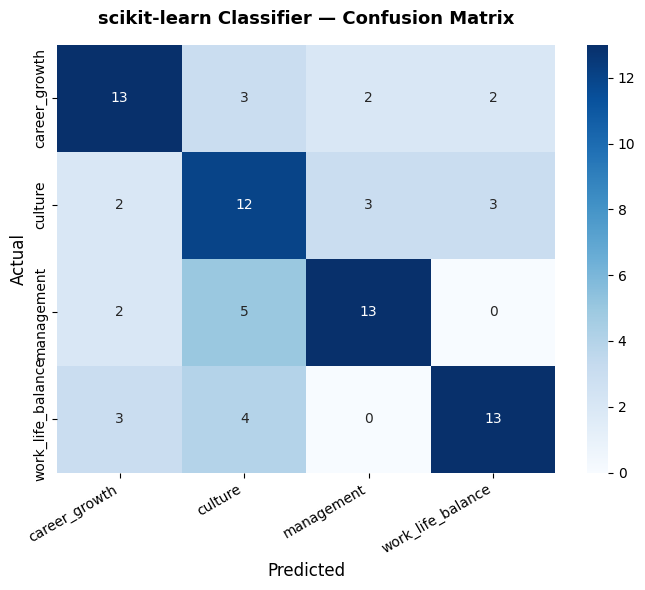


How to read this:
  Diagonal = correct predictions
  Off-diagonal = mistakes (actual vs predicted)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [14]:
# Shows where the model gets confused between themes

cm = confusion_matrix(y_test, y_pred_sklearn, labels=sorted(df['theme'].unique()))
labels = sorted(df['theme'].unique())

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels, ax=ax)
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('Actual', fontsize=12)
ax.set_title('scikit-learn Classifier — Confusion Matrix', fontsize=13, fontweight='bold', pad=15)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

print("\nHow to read this:")
print("  Diagonal = correct predictions")
print("  Off-diagonal = mistakes (actual vs predicted)")


In [15]:
# Check what model learned?
print("Top 10 words most associated with each theme:")
print("(These are the 'weights' the model learned)")
print("═" * 60)

feature_names = vectorizer.get_feature_names_out()

for theme in sorted(df['theme'].unique()):
    class_idx = list(classifier.classes_).index(theme)
    top_indices = classifier.coef_[class_idx].argsort()[-10:][::-1]
    top_words = [feature_names[i] for i in top_indices]
    print(f"\n{theme.upper().replace('_', ' ')}:")
    print("  " + ", ".join(top_words))


Top 10 words most associated with each theme:
(These are the 'weights' the model learned)
════════════════════════════════════════════════════════════

CAREER GROWTH:
  development, internal, role, professional, career, skills, training, new, year, asked

CULTURE:
  people, culture, bullying, real, feels, treated, discrimination, organisation, ideas, honest

MANAGEMENT:
  manager, management, leadership, person, feedback, change, changes, credit, leaders, boss

WORK LIFE BALANCE:
  hours, working, sleep, flexible, weekends, relentless, phone, deadlines, time, life


# Approach3: SetFit

#### what is SetFit?
SetFit stands for **Sentence Tranformer Fine-Tuning**. It's a different kind of model, instead of counting word frequencies, it understand the **meaning** of sentences.

The key difference:


|  | scikit-learn (TF-IDF)|SetFit
|---|---|---|
|How it presents text | Word frequency counts| Sentence meaning (embeddings)
|Training data needed | Needs lots of examples| Works well with very few (8-16 per class)
| Understand context? | No | Yes
| Accuracy on small data | Lower | Higher


Why I used SetFit?

Labelled survey data is expensive to create. We can't always get thousands of labelled examples (also think about the class imbalance). SetFit was designed for exactly this - **few-shot learning**, meaning it learns well from just a handful of examples per theme.

!!! We need GPU
SetFit takes longer to train the sklearn because it uses a pre-trained language model.

In [16]:
# SetFit expects data in HuggingFace Dataset format

from datasets import Dataset

# Use the same train/test split as before for a fair comparison
train_dataset = Dataset.from_dict({
    'text': X_train.tolist(),
    'label': y_train.tolist()
})

test_dataset = Dataset.from_dict({
    'text': X_test.tolist(),
    'label': y_test.tolist()
})

print(f"Training set : {len(train_dataset)} comments")
print(f"Test set     : {len(test_dataset)} comments")
print(f"\nSample training entry:")
print(f"  text  : {train_dataset[0]['text'][:80]}")
print(f"  label : {train_dataset[0]['label']}")


Training set : 320 comments
Test set     : 80 comments

Sample training entry:
  text  : I've never felt the need to filter myself in meetings
  label : culture


In [17]:
# We use a small, fast sentence transformer as the base model.
# 'paraphrase-MiniLM-L3-v2' is lightweight and good for short texts.

print("Loading SetFit base model...")
print("(This downloads ~30MB on first run)\n")

model = SetFitModel.from_pretrained(
    "sentence-transformers/paraphrase-MiniLM-L3-v2", # smaller model as our sample is very small
    labels=sorted(df['theme'].unique())
)

model.to(device)

print("Model loaded")
print(f"Labels: {model.labels}")


Loading SetFit base model...
(This downloads ~30MB on first run)



config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

model_head.pkl not found on HuggingFace Hub, initialising classification head with random weights. You should TRAIN this model on a downstream task to use it for predictions and inference.


Model loaded
Labels: ['career_growth', 'culture', 'management', 'work_life_balance']


In [29]:
# ── TRAIN SETFIT (or load a pre-trained one from my Google Drive) ────────────
# SetFit training has two phases:
#   Phase 1: Fine-tune the sentence transformer on pairs of examples
#   Phase 2: Train a classifier head on the sentence embeddings
#
# This can take 3-5 minutes in Colab -- too long for a live session.
# Set USE_PRETRAINED = True to load a model already saved to Google Drive
# (see the one-off SAVE TO DRIVE cell above), and skip training entirely.

USE_PRETRAINED = True
SAVED_MODEL_PATH = "/content/drive/MyDrive/coffee_and_coding_setfit_model"

import os
if USE_PRETRAINED:
    # Mount Drive first so the exists-check below can actually see the file
    from google.colab import drive
    drive.mount("/content/drive")
if USE_PRETRAINED and not os.path.exists(SAVED_MODEL_PATH):
    print(f"No saved model found at '{SAVED_MODEL_PATH}' -- training live instead.")
    USE_PRETRAINED = False

if USE_PRETRAINED:
    print(f"Loading pre-trained model from '{SAVED_MODEL_PATH}' (skipping live training)...")
    model = SetFitModel.from_pretrained(SAVED_MODEL_PATH)
    if device.type == "cuda":
        model.to(device)
    print("Model loaded -- ready to evaluate.")
else:
    # Note: newer transformers/setfit versions renamed "evaluation_strategy" to
    # "eval_strategy". We try the current name first and fall back automatically
    # so this cell keeps working even if Colab installs a different version.
    try:
        args = TrainingArguments(
            batch_size=16,
            num_epochs=3,
            eval_strategy="epoch",
            save_strategy="epoch",
            load_best_model_at_end=True,
        )
    except TypeError:
        args = TrainingArguments(
            batch_size=16,
            num_epochs=3,
            evaluation_strategy="epoch",
            save_strategy="epoch",
            load_best_model_at_end=True,
        )

    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=train_dataset,
        eval_dataset=test_dataset,
        metric="accuracy",
    )

    print("Starting SetFit training...")
    print("─" * 40)
    trainer.train()
    print("\nTraining complete")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loading pre-trained model from '/content/drive/MyDrive/coffee_and_coding_setfit_model' (skipping live training)...
Model loaded -- ready to evaluate.


In [30]:
# EVALUATE SETFIT
# We evaluate model.predict() directly rather than trainer.evaluate() --
# this works the same way whether the model above was trained live or
# loaded from a saved checkpoint.

setfit_preds = model.predict(X_test.tolist())
setfit_accuracy = accuracy_score(y_test, setfit_preds)

print(f"SetFit Accuracy: {setfit_accuracy:.1%}")
print()

print("Full classification report:")
print("─" * 60)
print(classification_report(y_test, setfit_preds, target_names=sorted(df['theme'].unique())))


SetFit Accuracy: 78.8%

Full classification report:
────────────────────────────────────────────────────────────
                   precision    recall  f1-score   support

    career_growth       0.76      0.80      0.78        20
          culture       0.88      0.75      0.81        20
       management       0.73      0.80      0.76        20
work_life_balance       0.80      0.80      0.80        20

         accuracy                           0.79        80
        macro avg       0.79      0.79      0.79        80
     weighted avg       0.79      0.79      0.79        80



/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


**SetFit: 79% accuracy** : a solid jump from TF-IDF's 63.7%, and every theme is now performing reasonably well, with none dropping below 0.73 on any measure.

The clearest improvement is `culture` it was TF-IDF's weak spot (0.50 precision), and it's now the *strongest* theme here (0.88 precision). When SetFit says "culture," it's right 88% of the time which is aa big shift from words alone to actually picking up on meaning, which is exactly the gap indirect comments were designed to expose.

`management` is now the relative weak point (0.73 precision) — not bad, but the one theme SetFit is least confident calling correctly. Worth a quick look at the confusion matrix to see what it's mixing management up with, the same way we did for TF-IDF.

Recall is close and consistent across all four themes (0.75 ~ 0.80) — no theme is being badly missed, unlike TF-IDF where management and work_life_balance had noticeably lower recall than precision. That balance between precision and recall across the board is a good sign the model isn't just getting lucky on one theme while quietly failing another.

#### Confidence thresholds

SetFit doesn not just output a theme, it outputs a **probablity** for every theme, and we can use that to decide how much to trust each prediction. This is how I used for my recent project.

| Confidence | Action |
|---|---|
| **HIGH** (≥ 0.80) | Auto-accept the prediction |
| **MEDIUM** (≥ 0.50) | Flag for human review |
| **LOW** (< 0.50) | Send for manual classification |



In [31]:
# CONFIDENCE-BASED ACCEPT / REVIEW SPLIT

HIGH_THRESHOLD = 0.80
MEDIUM_THRESHOLD = 0.50

# predict_proba gives us one probability per theme for each comment
proba = model.predict_proba(X_test.tolist())
proba = np.array(proba)
confidence = proba.max(axis=1)

def bucket(p):
    if p >= HIGH_THRESHOLD:
        return "HIGH (auto-accept)"
    elif p >= MEDIUM_THRESHOLD:
        return "MEDIUM (review)"
    else:
        return "LOW (manual)"

conf_df = pd.DataFrame({
    'comment': X_test.tolist(),
    'actual': y_test.tolist(),
    'predicted': setfit_preds,
    'confidence': confidence,
})
conf_df['bucket'] = conf_df['confidence'].apply(bucket)
conf_df['correct'] = conf_df['actual'] == conf_df['predicted']

print("Volume and accuracy by confidence bucket:")
print("═" * 60)
summary = conf_df.groupby('bucket').agg(
    count=('correct', 'size'),
    accuracy=('correct', 'mean'),
).reindex(["HIGH (auto-accept)", "MEDIUM (review)", "LOW (manual)"])
summary['share_of_test_set'] = summary['count'] / len(conf_df)
print(summary.round(2))

print(f"\n{summary.loc['HIGH (auto-accept)', 'share_of_test_set']:.0%} of comments would be "
      f"auto-accepted at the HIGH threshold, with "
      f"{summary.loc['HIGH (auto-accept)', 'accuracy']:.0%} accuracy on that subset.")


Volume and accuracy by confidence bucket:
════════════════════════════════════════════════════════════
                    count  accuracy  share_of_test_set
bucket                                                
HIGH (auto-accept)   78.0      0.79               0.98
MEDIUM (review)       2.0      0.50               0.02
LOW (manual)          NaN       NaN                NaN

98% of comments would be auto-accepted at the HIGH threshold, with 79% accuracy on that subset.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


# Comparison

Now let's put all three approaches side by side and see which performs best — and understand *why*.



In [32]:
# SUMMARY TABLE
# Recalculate keyword accuracy on test set only (for a fair comparison)
# We report BOTH "accuracy on classified" and the fairer "overall accuracy"
# (treating an unclassified comment as a miss, since that's what happens
# to it in a real reporting pipeline).

df_test = pd.DataFrame({'comment': X_test, 'theme': y_test})
df_test['keyword_pred'] = df_test['comment'].apply(
    lambda x: classify_with_keywords(x, keyword_rules)
)

classified_test = df_test[df_test['keyword_pred'] != 'unclassified']
kw_accuracy_test = accuracy_score(classified_test['theme'], classified_test['keyword_pred']) if len(classified_test) else 0
kw_coverage = len(classified_test) / len(df_test)
kw_overall_test = accuracy_score(df_test['theme'], df_test['keyword_pred'])

print("=" * 78)
print(f"{'Method':<25} {'Accuracy*':>12} {'Coverage':>10} {'Overall accuracy':>18}")
print("=" * 78)
print(f"{'Keyword Matching':<25} {kw_accuracy_test:>11.1%} {kw_coverage:>9.1%} {kw_overall_test:>17.1%}")
print(f"{'scikit-learn (TF-IDF)':<25} {sklearn_accuracy:>11.1%} {'100%':>10} {sklearn_accuracy:>17.1%}")
print(f"{'SetFit':<25} {setfit_accuracy:>11.1%} {'100%':>10} {setfit_accuracy:>17.1%}")
print("=" * 78)
print()
print("*Accuracy on classified   = % correct, of only the comments the method attempted")
print("Coverage                 = % of comments the method was willing to classify")
print("Overall accuracy         = % correct out of ALL comments (unclassified = wrong)")
print("                            — this is the fair, real-world comparison")


Method                       Accuracy*   Coverage   Overall accuracy
Keyword Matching                78.3%     57.5%             45.0%
scikit-learn (TF-IDF)           63.7%       100%             63.7%
SetFit                          78.8%       100%             78.8%

*Accuracy on classified   = % correct, of only the comments the method attempted
Coverage                 = % of comments the method was willing to classify
Overall accuracy         = % correct out of ALL comments (unclassified = wrong)
                            — this is the fair, real-world comparison


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


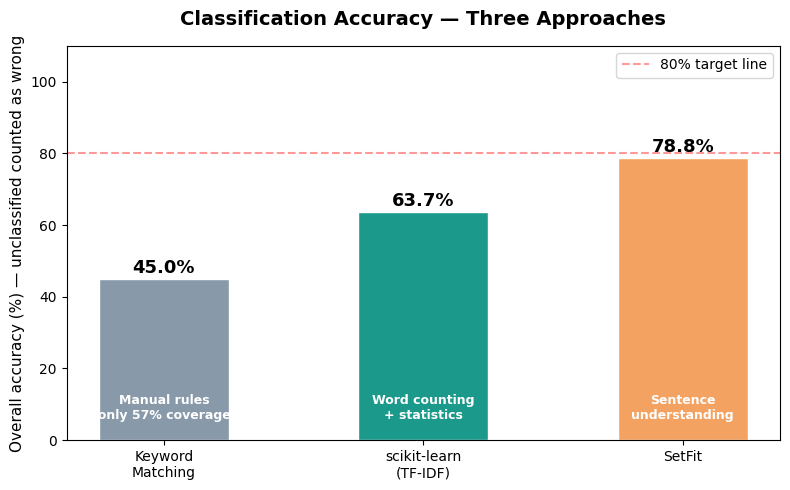

Note: keyword matching's 'accuracy on classified' figure looked competitive earlier,
but once you count the 43% of comments it couldn't classify at all,
its real-world accuracy tells a very different story.


In [33]:
#  VISUAL COMPARISON
# We chart OVERALL accuracy (unclassified = wrong) — the fair, real-world measure.

methods = ['Keyword\nMatching', 'scikit-learn\n(TF-IDF)', 'SetFit']
accuracies = [kw_overall_test * 100, sklearn_accuracy * 100, setfit_accuracy * 100]
colors = ['#8899AA', '#1B998B', '#F4A261']

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(methods, accuracies, color=colors, edgecolor='white', width=0.5)

# Add value labels on bars
for bar, val in zip(bars, accuracies):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.5,
            f'{val:.1f}%',
            ha='center', va='bottom', fontweight='bold', fontsize=13)

ax.set_ylim(0, 110)
ax.set_ylabel('Overall accuracy (%) — unclassified counted as wrong', fontsize=11)
ax.set_title('Classification Accuracy — Three Approaches', fontsize=14, fontweight='bold', pad=15)
ax.axhline(y=80, color='red', linestyle='--', alpha=0.4, label='80% target line')
ax.legend()

# Annotate what each is
annotations = [
    f"Manual rules\n(only {kw_coverage:.0%} coverage)",
    "Word counting\n+ statistics",
    "Sentence\nunderstanding"
]
for bar, note in zip(bars, annotations):
    ax.text(bar.get_x() + bar.get_width() / 2,
            5, note,
            ha='center', va='bottom', fontsize=9,
            color='white', fontweight='bold')

plt.tight_layout()
plt.show()

print("Note: keyword matching's 'accuracy on classified' figure looked competitive earlier,")
print(f"but once you count the {100 - kw_coverage*100:.0f}% of comments it couldn't classify at all,")
print("its real-world accuracy tells a very different story.")


## Does direct vs indirect language matter for ML too?

We saw earlier that keyword matching's coverage collapses on indirect comments. Do the ML approaches hold up better? Let's break accuracy down by comment style for all three methods, using the `difficulty` column that came with the CSV.


In [34]:
# ── ACCURACY BY DIFFICULTY ── ACROSS ALL THREE METHODS ──────────────────────────
# X_test keeps its original DataFrame index, so we can look difficulty up from df
test_difficulty = df.loc[X_test.index, 'difficulty'].values

results = pd.DataFrame({
    'difficulty': test_difficulty,
    'actual': y_test.values,
    'keyword': df_test['keyword_pred'].values,
    'sklearn': y_pred_sklearn,
    'setfit': setfit_preds,
})

rows = []
for method in ['keyword', 'sklearn', 'setfit']:
    for diff in ['direct', 'indirect']:
        sub = results[results['difficulty'] == diff]
        acc = (sub[method] == sub['actual']).mean()
        rows.append({'method': method, 'difficulty': diff, 'accuracy': acc, 'n': len(sub)})

breakdown = pd.DataFrame(rows).pivot(index='method', columns='difficulty', values='accuracy')
breakdown = breakdown.reindex(['keyword', 'sklearn', 'setfit'])
breakdown['gap (direct - indirect)'] = breakdown['direct'] - breakdown['indirect']

print("Accuracy by comment style (unclassified counted as wrong for keyword matching):")
print("═" * 60)
print((breakdown * 100).round(1).astype(str) + '%')
print()
print("The smaller the gap, the less a method relies on people using 'expected' wording.")


Accuracy by comment style (unclassified counted as wrong for keyword matching):
════════════════════════════════════════════════════════════
difficulty direct indirect gap (direct - indirect)
method                                            
keyword     65.2%    17.6%                   47.6%
sklearn     71.7%    52.9%                   18.8%
setfit      82.6%    73.5%                    9.1%

The smaller the gap, the less a method relies on people using 'expected' wording.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [35]:
# ── TEST ON YOUR OWN COMMENTS ────────────────────────────────────────────────
# Try the three classifiers on comments you write yourself!

your_comments = [
    "I feel completely undervalued and my ideas are always ignored",
    "The management team here is excellent and always supportive",
    "No opportunity to develop skills or move up in this organisation",
    "The hours are brutal and I never get to see my family",
    # Add your own here ↓
]

print("Your comments — classified by all three approaches:")
print("─" * 80)

for comment in your_comments:
    kw  = classify_with_keywords(comment, keyword_rules)

    comment_vec = vectorizer.transform([comment])
    sk  = classifier.predict(comment_vec)[0]

    sf  = model.predict([comment])[0]

    print(f"Comment   : {comment}")
    print(f"Keyword   : {kw}")
    print(f"sklearn   : {sk}")
    print(f"SetFit    : {sf}")
    print()


Your comments — classified by all three approaches:
────────────────────────────────────────────────────────────────────────────────
Comment   : I feel completely undervalued and my ideas are always ignored
Keyword   : unclassified
sklearn   : culture
SetFit    : culture

Comment   : The management team here is excellent and always supportive
Keyword   : management
sklearn   : management
SetFit    : management

Comment   : No opportunity to develop skills or move up in this organisation
Keyword   : career_growth
sklearn   : career_growth
SetFit    : career_growth

Comment   : The hours are brutal and I never get to see my family
Keyword   : work_life_balance
sklearn   : work_life_balance
SetFit    : work_life_balance



/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [37]:
# if you wish, you can save

# ── EXPORT COMBINED RESULTS ─────────────────────────────────────────────
export_df = pd.DataFrame({
    'comment': X_test.tolist(),
    'difficulty': df.loc[X_test.index, 'difficulty'].values,
    'actual_theme': y_test.tolist(),
    'keyword_prediction': df_test['keyword_pred'].values,
    'sklearn_prediction': y_pred_sklearn,
    'setfit_prediction': setfit_preds,
    'setfit_confidence': confidence,
    'setfit_bucket': conf_df['bucket'].values,
})

export_path = "classification_results.csv"
export_df.to_csv(export_path, index=False)
print(f"Saved {len(export_df)} rows to {export_path}")

try:
    from google.colab import files
    files.download(export_path)
except ImportError:
    pass

export_df.head()


Saved 80 rows to classification_results.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

,comment,difficulty,actual_theme,keyword_prediction,sklearn_prediction,setfit_prediction,setfit_confidence,setfit_bucket
0,My manager encourages me to challenge decision...,direct,management,management,management,management,0.998928,HIGH (auto-accept)
1,Colleagues are supportive and look out for eac...,direct,culture,management,work_life_balance,management,0.943205,HIGH (auto-accept)
2,"The learning platform here has excellent, rele...",direct,career_growth,career_growth,career_growth,career_growth,0.631978,MEDIUM (review)
3,I've asked about progression three times with ...,direct,career_growth,work_life_balance,career_growth,career_growth,0.998988,HIGH (auto-accept)
4,Regular one-to-ones with my manager are genuin...,direct,management,management,management,management,0.998937,HIGH (auto-accept)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


---
## Wrap Up — What Did We Learn?

The chart above tells the real story: keyword matching's headline accuracy looked competitive, but once you count the comments it couldn't even attempt, its true accuracy drops well behind the two learning-based approaches. That gap is the whole point of today's session — it's why the CI team invested in ML in the first place.

### The three approaches, in plain English

| Approach | What it does | Strength | Weakness |
|----------|-------------|----------|----------|
| **Keyword matching** | Looks for specific words you define | Transparent, simple, no data needed | Misses context, needs constant maintenance |
| **scikit-learn TF-IDF** | Learns word patterns from examples | Fast, good with lots of data | Doesn't understand meaning |
| **SetFit** | Understands sentence meaning | Accurate with few examples, handles nuance | Slower, needs a GPU ideally |

All three approaches are doing the same thing at their core — what we covered in the slide deck:

- **Inputs** (x) = the words or features in the comment
- **Weights** (w) = how strongly each feature signals each theme
- **Threshold** = the decision boundary between themes
- **Output** = the predicted theme

The difference is *how* the weights are set:
- Keyword matching: **you set them manually**
- scikit-learn: **set by counting and statistics**
- SetFit: **set by understanding meaning**, using a pre-trained language model

---

### Where to go next

- **SetFit paper**: https://arxiv.org/abs/2209.11055
- **scikit-learn docs**: https://scikit-learn.org/stable/
- **Hugging Face SetFit**: https://huggingface.co/docs/setfit
- **3Blue1Brown neural networks**: https://www.youtube.com/watch?v=aircAruvnKk
